# 🛒 Análise Preditiva de Vendas e Lucratividade — Superstore
## MVP — Sistema de Suporte à Tomada de Decisão em Engenharia de Produção

---

| Campo | Informação |
|---|---|
| **Aluna** | Maria Gabriela Soares Canabrava Mascarenhas |
| **Matrícula** | 202043405 |
| **Universidade** | Universidade de Brasília (UnB) |
| **Departamento** | Engenharia de Produção |
| **Disciplina** | Sistema de Suporte à Tomada de Decisão |
| **Professor** | Dr. André Luiz Marques Serrano |
| **Data** | Abril de 2026 |

---

## Resumo

Este notebook apresenta um trabalho de Machine Learning aplicado a dados reais de vendas de uma rede varejista (dataset **Superstore Sales**), estruturado em **duas frentes analíticas complementares** sobre a mesma base de dados:

**Bloco 1 — Regressão Supervisionada:** predição do **lucro (`Profit`)** de uma transação de venda a partir de atributos como valor vendido, quantidade, desconto aplicado, categoria do produto, segmento de cliente e região — com treinamento, otimização de hiperparâmetros e comparação de múltiplos modelos (Regressão Linear, Ridge, Random Forest, Gradient Boosting).

**Bloco 2 — Análise de Séries Temporais:** modelagem da **evolução mensal das vendas (`Sales`)** ao longo de 4 anos, incluindo decomposição de tendência e sazonalidade, testes de estacionariedade, e previsão (forecast) com modelo SARIMA.

A combinação dos dois blocos demonstra como o mesmo conjunto de dados pode ser utilizado para responder a duas perguntas distintas e complementares de negócio: *"o que determina a lucratividade de uma venda?"* (regressão) e *"como as vendas evoluirão nos próximos meses?"* (série temporal) — ambas relevantes para o suporte à tomada de decisão em uma operação de varejo.

---


---
## 0. Configuração do Ambiente


In [1]:
# Instalação de dependências extras (caso necessário no Colab)
!pip install -q statsmodels pmdarima


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
# ─── Importações ────────────────────────────────────────────────────────────

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Pré-processamento e pipelines (Bloco 1 — Regressão)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression

# Modelos de regressão
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor

# Validação e métricas
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Séries temporais (Bloco 2)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Reprodutibilidade e formatação
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Configuração visual global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("✅ Ambiente configurado com sucesso!")


✅ Ambiente configurado com sucesso!


---
## 1. Definição do Problema

### 1.1 Contexto

Uma rede varejista (Superstore) precisa tomar duas decisões centrais e complementares para sustentar sua operação:

1. **Quais transações de venda tendem a ser lucrativas ou gerar prejuízo?** — relevante para definir políticas de desconto e priorização de categorias/segmentos.
2. **Como as vendas totais evoluirão nos próximos meses?** — relevante para planejamento de estoque, fluxo de caixa e metas comerciais.

Este trabalho aborda as duas perguntas utilizando o mesmo dataset, através de duas técnicas de Machine Learning distintas: **regressão supervisionada** (Bloco 1) e **modelagem de séries temporais** (Bloco 2).

---

### 1.2 Tipo de Tarefa

| Bloco | Tarefa | Variável-alvo | Granularidade |
|---|---|---|---|
| 1 — Regressão | Regressão supervisionada | `Profit` (lucro por transação, US$) | Transação individual |
| 2 — Série Temporal | Forecast / análise temporal | `Sales` (vendas agregadas, US$) | Mensal (série agregada) |

---

### 1.3 Premissas e Hipóteses Iniciais

Antes de qualquer análise dos dados, partimos das seguintes **premissas** sobre o domínio do problema: assumimos que o lucro de uma transação é determinado principalmente por fatores observáveis no momento da venda (valor vendido, desconto, categoria do produto), e que o volume de vendas ao longo do tempo segue um comportamento influenciado por sazonalidade típica de varejo (datas comemorativas, fim de ano). A partir dessas premissas, formulamos as seguintes **hipóteses** testáveis:

**Bloco 1 — Regressão (lucratividade):**

| # | Hipótese |
|---|---|
| H1 | Descontos elevados reduzem fortemente o lucro, podendo gerar prejuízo |
| H2 | A categoria do produto influencia a margem de lucro |
| H3 | O valor de venda (`Sales`) tem relação positiva, mas não linear, com o lucro |
| H4 | Região e modo de envio têm influência secundária na lucratividade |

**Bloco 2 — Série Temporal (vendas mensais):**

| # | Hipótese |
|---|---|
| H5 | As vendas apresentam tendência de crescimento ao longo dos 4 anos |
| H6 | Há sazonalidade anual, com picos em determinados meses (ex: novembro, dezembro) |
| H7 | A série não é estacionária em nível, exigindo diferenciação para modelagem |

---

### 1.4 Descrição do Dataset

- **Nome:** Superstore Sales Dataset
- **Fonte:** Repositório público no GitHub (espelhamento do dataset clássico de Tableau/Kaggle)
- **Registros:** 9.994 transações de venda
- **Período:** Janeiro de 2014 a Dezembro de 2017 (4 anos completos)
- **Valores faltantes:** Nenhum

| Atributo | Tipo | Descrição |
|---|---|---|
| `Order Date` | Data | Data do pedido (usada na série temporal) |
| `Sales` | Numérico | Valor de venda da transação (US$) |
| `Quantity` | Numérico | Quantidade de itens vendidos |
| `Discount` | Numérico | Percentual de desconto aplicado (0 a 0,8) |
| `Category` | Categórico | Categoria do produto (Furniture, Office Supplies, Technology) |
| `Segment` | Categórico | Segmento do cliente (Consumer, Corporate, Home Office) |
| `Region` | Categórico | Região dos EUA (South, West, Central, East) |
| `Ship Mode` | Categórico | Modo de envio (Standard, Second Class, First Class, Same Day) |
| `Profit` | Numérico (alvo Bloco 1) | Lucro da transação (US$), pode ser negativo |

---

### 1.5 Restrições de Seleção dos Dados

- Dataset não utilizado nas disciplinas da sprint
- Carregado diretamente via URL pública, sem necessidade de configuração manual
- Possui granularidade temporal real (datas diárias por 4 anos), adequado tanto para regressão transacional quanto para análise de série temporal agregada
- Dataset público, sem restrições de uso para fins educacionais


---
## 2. Carregamento e Inspeção Inicial dos Dados


In [3]:
# ─── Carregamento do dataset via URL ────────────────────────────────────────
URL = "https://raw.githubusercontent.com/yajasarora/Superstore-Sales-Analysis-with-Tableau/master/Superstore%20sales%20dataset.csv"
df = pd.read_csv(URL, encoding='utf-8-sig')

# Conversão da coluna de data (o dataset contém formatos mistos dd/mm e mm/dd)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=False)

print(f"✅ Dataset carregado com sucesso!")
print(f"   Shape: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"   Período: {df['Order Date'].min().date()} a {df['Order Date'].max().date()}")


✅ Dataset carregado com sucesso!
   Shape: 9994 linhas × 21 colunas
   Período: 2014-01-02 a 2017-12-30


In [4]:
# ─── Primeiras linhas ────────────────────────────────────────────────────────
df.head(10)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,2014-09-06,14/6/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,2014-09-06,14/6/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,2014-09-06,14/6/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,2014-09-06,14/6/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,2014-09-06,14/6/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [5]:
# ─── Tipos de dados e valores faltantes ─────────────────────────────────────
print("📋 Informações do Dataset:")
print(f"{'Coluna':<15} {'Tipo':<18} {'Nulos':<8} {'Únicos'}")
print("-" * 55)
for col in df.columns:
    print(f"{col:<15} {str(df[col].dtype):<18} {df[col].isnull().sum():<8} {df[col].nunique()}")


📋 Informações do Dataset:
Coluna          Tipo               Nulos    Únicos
-------------------------------------------------------
Row ID          int64              0        9994
Order ID        str                0        5009
Order Date      datetime64[us]     0        1237
Ship Date       str                0        1334
Ship Mode       str                0        4
Customer ID     str                0        793
Customer Name   str                0        793
Segment         str                0        3
Country         str                0        1
City            str                0        531


State           str                0        49
Postal Code     int64              0        631
Region          str                0        4
Product ID      str                0        1862
Category        str                0        3
Sub-Category    str                0        17
Product Name    str                0        1850
Sales           float64            0        5825
Quantity        int64              0        14
Discount        float64            0        12
Profit          float64            0        7287


In [6]:
# ─── Estatísticas descritivas das variáveis numéricas ────────────────────────
print("📊 Estatísticas Descritivas:")
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)


📊 Estatísticas Descritivas:


,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


In [7]:
# ─── Distribuição das variáveis categóricas relevantes ───────────────────────
print("📊 Distribuição das Variáveis Categóricas:\n")
for col in ['Category', 'Segment', 'Region', 'Ship Mode']:
    print(f"  {col.upper()}:")
    print(df[col].value_counts().to_string())
    print()


📊 Distribuição das Variáveis Categóricas:

  CATEGORY:
Category
Office Supplies    6026
Furniture          2121
Technology         1847

  SEGMENT:
Segment
Consumer       5191
Corporate      3020
Home Office    1783

  REGION:
Region
West       3203
East       2848
Central    2323
South      1620

  SHIP MODE:
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543



---
---
# 🟦 BLOCO 1 — Regressão Supervisionada: Predição de Lucro (`Profit`)

---
## 3. Análise Exploratória de Dados (EDA) — Bloco 1

Nesta etapa investigamos a relação entre os atributos da transação e o lucro, buscando confirmar (ou refutar) as hipóteses H1 a H4.


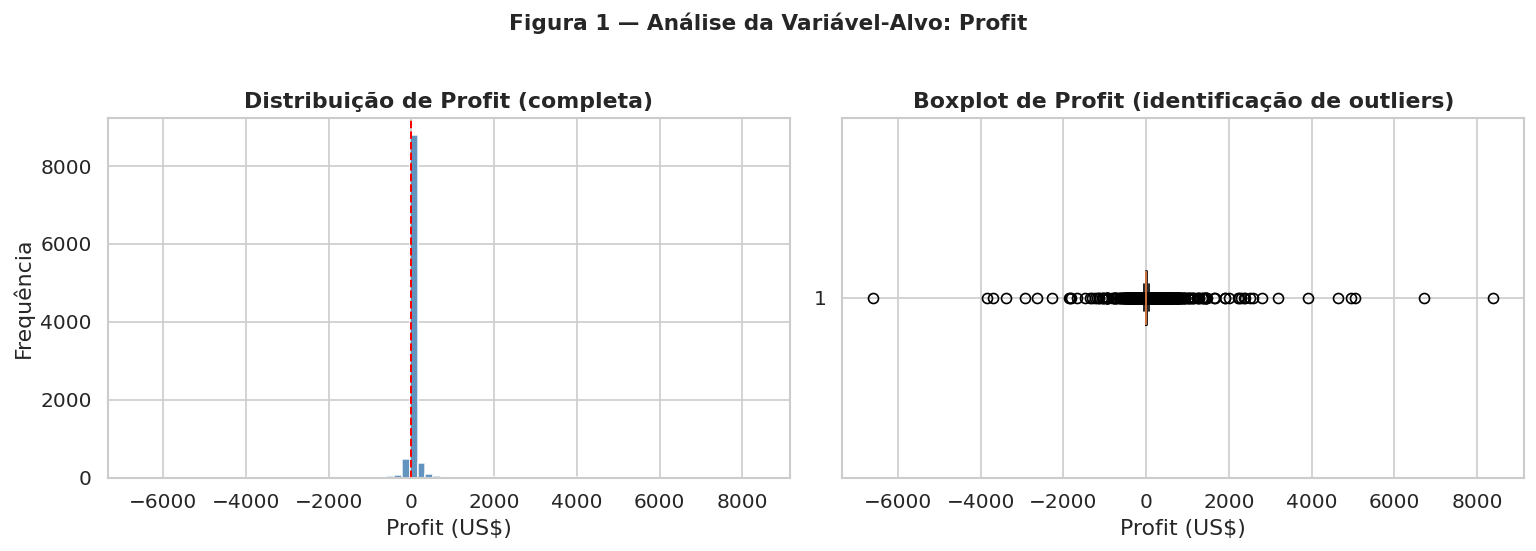


💡 Transações com prejuízo (Profit < 0): 1871 (18.7%)


In [8]:
# ─── Distribuição de Profit ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['Profit'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição de Profit (completa)', fontweight='bold')
axes[0].set_xlabel('Profit (US$)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(0, color='red', linestyle='--', lw=1.2)

axes[1].boxplot(df['Profit'], vert=False)
axes[1].set_title('Boxplot de Profit (identificação de outliers)', fontweight='bold')
axes[1].set_xlabel('Profit (US$)')

plt.suptitle('Figura 1 — Análise da Variável-Alvo: Profit', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

pct_negativo = (df['Profit'] < 0).mean() * 100
print(f"\n💡 Transações com prejuízo (Profit < 0): {(df['Profit']<0).sum()} ({pct_negativo:.1f}%)")


**Ponto de atenção identificado:** a distribuição de `Profit` apresenta outliers extremos em ambas as direções (lucros de até ~US\$8.400 e prejuízos de até ~US\$6.600 em transações isoladas). Esses valores extremos, embora reais, distorcem fortemente o treinamento dos modelos de regressão — um teste preliminar mostrou R² negativo no conjunto de teste quando os outliers são mantidos. Trataremos isso explicitamente na Etapa 4 (Preparação dos Dados).


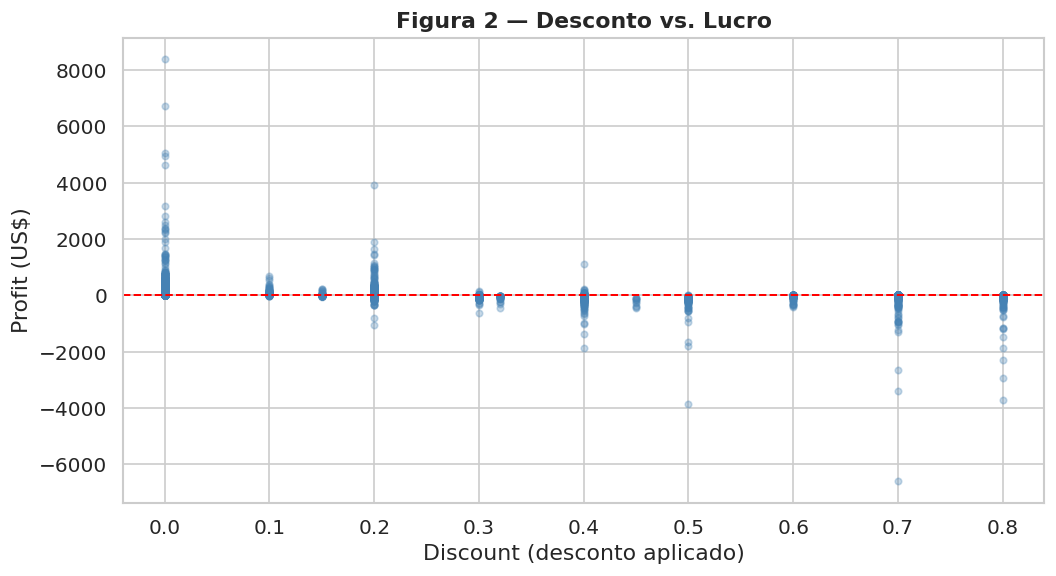

📌 Correlação Discount × Profit: -0.219 → confirma H1 (relação negativa)


In [9]:
# ─── Relação entre Discount e Profit ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, s=15, color='steelblue')
ax.axhline(0, color='red', linestyle='--', lw=1.2)
ax.set_xlabel('Discount (desconto aplicado)')
ax.set_ylabel('Profit (US$)')
ax.set_title('Figura 2 — Desconto vs. Lucro', fontweight='bold')
plt.tight_layout()
plt.show()

corr_disc = df['Discount'].corr(df['Profit'])
print(f"📌 Correlação Discount × Profit: {corr_disc:.3f} → confirma H1 (relação negativa)")


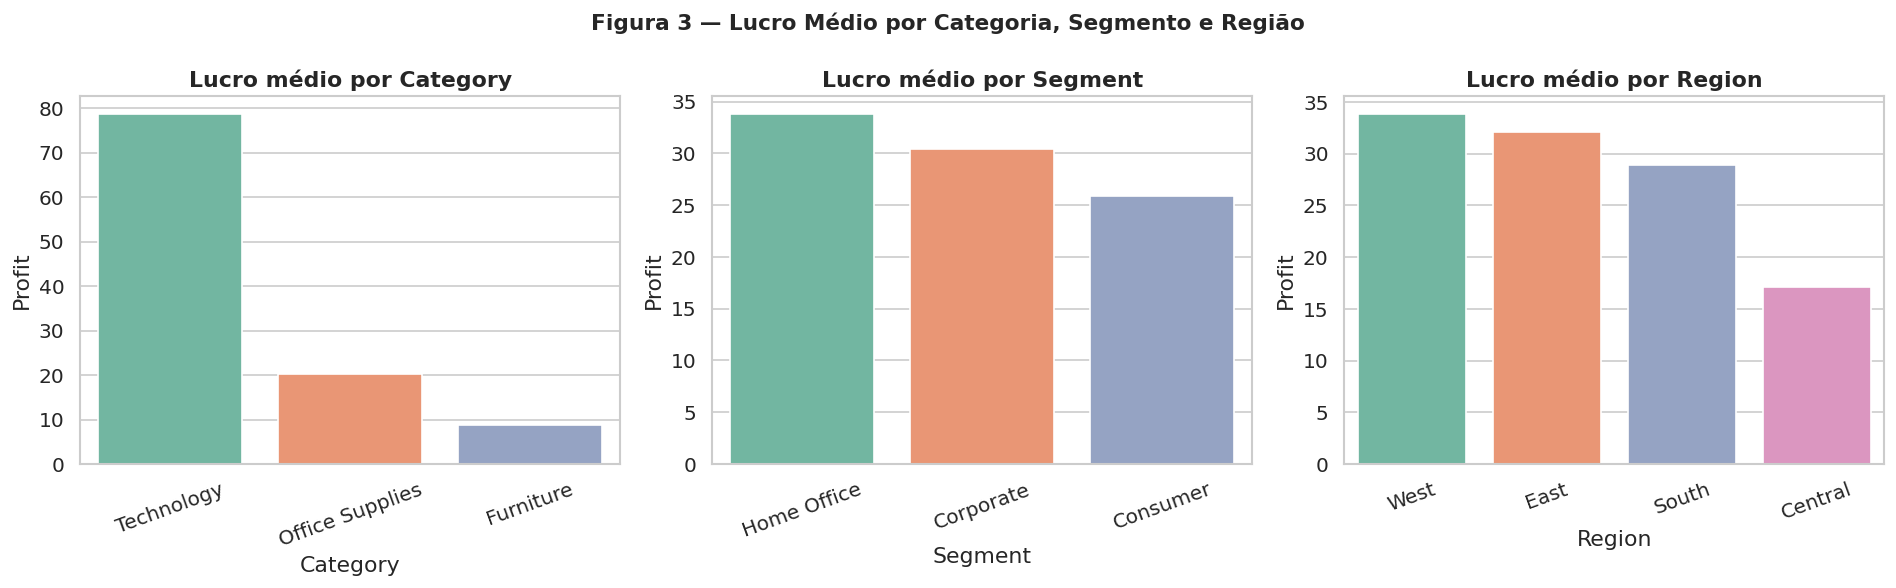

In [10]:
# ─── Lucro médio por categoria, segmento e região ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Category', 'Segment', 'Region']):
    order = df.groupby(col)['Profit'].mean().sort_values(ascending=False).index
    sns.barplot(data=df, x=col, y='Profit', order=order, ax=ax,
                estimator=np.mean, errorbar=None, palette='Set2')
    ax.set_title(f'Lucro médio por {col}', fontweight='bold')
    ax.axhline(0, color='red', linestyle='--', lw=1)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Figura 3 — Lucro Médio por Categoria, Segmento e Região', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


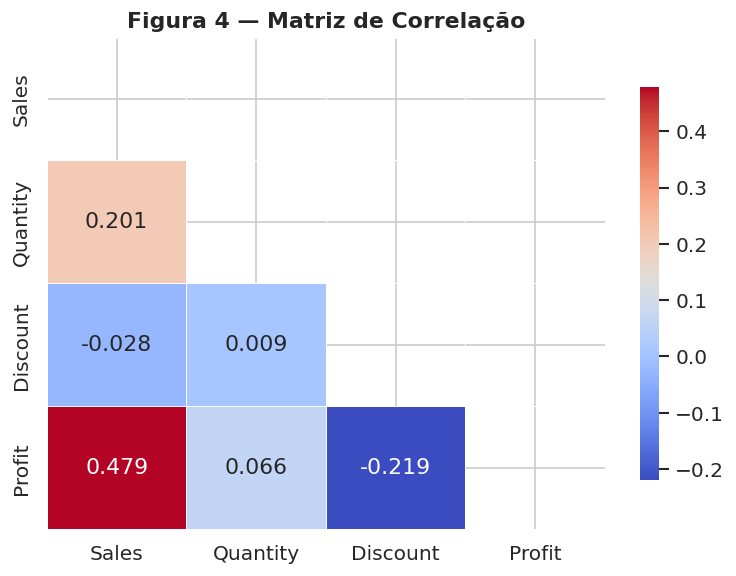

In [11]:
# ─── Matriz de correlação (variáveis numéricas) ──────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 5))
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', mask=mask, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Figura 4 — Matriz de Correlação', fontweight='bold')
plt.tight_layout()
plt.show()


### Síntese da EDA — Bloco 1

| Hipótese | Resultado |
|---|---|
| H1 — Desconto reduz o lucro | ✅ Confirmada — correlação negativa relevante, prejuízo concentrado em descontos altos |
| H2 — Categoria influencia a margem | ✅ Confirmada — diferenças visíveis no lucro médio entre categorias |
| H3 — Sales tem relação positiva, não-linear | ✅ Confirmada — dispersão grande sugere efeitos de interação (ex: Sales × Discount) |
| H4 — Região e Ship Mode têm influência secundária | ✅ Confirmada — variações menores comparadas a Discount e Category |


---
## 4. Preparação dos Dados — Bloco 1

### 4.1 Tratamento de Outliers

Conforme identificado na EDA, valores extremos de `Profit` prejudicam o treinamento. Aplicamos o método do **Intervalo Interquartil (IQR)** com um fator de 3 (mais permissivo que o tradicional 1.5, removendo apenas os outliers mais extremos e preservando a maior parte da variabilidade real dos dados):

$$\text{Limite inferior} = Q_1 - 3 \times IQR \qquad \text{Limite superior} = Q_3 + 3 \times IQR$$


In [12]:
# ─── Remoção de outliers extremos via IQR ────────────────────────────────────
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

df_reg = df[(df['Profit'] >= lower_bound) & (df['Profit'] <= upper_bound)].copy()

print(f"📐 Limites IQR (fator 3): [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"   Registros originais: {len(df)}")
print(f"   Registros removidos: {len(df) - len(df_reg)} ({(len(df)-len(df_reg))/len(df)*100:.1f}%)")
print(f"   Registros restantes:  {len(df_reg)}")


📐 Limites IQR (fator 3): [-81.18, 112.27]
   Registros originais: 9994
   Registros removidos: 1168 (11.7%)
   Registros restantes:  8826


### 4.2 Separação Treino / Teste


In [13]:
# ─── Definição de X e y ──────────────────────────────────────────────────────
feature_cols = ['Sales', 'Quantity', 'Discount', 'Category', 'Segment', 'Region', 'Ship Mode']
X = df_reg[feature_cols].copy()
y = df_reg['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Separação concluída:")
print(f"   Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Teste:  {X_test.shape[0]}  amostras ({X_test.shape[0]/len(X)*100:.0f}%)")


✅ Separação concluída:
   Treino: 7060 amostras (80%)
   Teste:  1766  amostras (20%)


### 4.3 Pipeline de Pré-processamento

- **Variáveis numéricas** (`Sales`, `Quantity`, `Discount`): padronizadas com `StandardScaler`
- **Variáveis categóricas** (`Category`, `Segment`, `Region`, `Ship Mode`): codificadas com `OneHotEncoder` (`drop='first'` para evitar multicolinearidade)

O `ColumnTransformer` garante que o `fit` ocorra apenas no treino, evitando data leakage.


In [14]:
# ─── Pré-processador via ColumnTransformer ────────────────────────────────────
numeric_features     = ['Sales', 'Quantity', 'Discount']
categorical_features = ['Category', 'Segment', 'Region', 'Ship Mode']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Pré-processador e K-Fold (k=5) configurados")


✅ Pré-processador e K-Fold (k=5) configurados


### 4.4 Seleção de Atributos (Feature Selection)

Após o encoding das variáveis categóricas, o número de atributos aumenta (cada categoria se transforma em uma ou mais colunas binárias). Para refinar a quantidade de atributos disponíveis e reduzir ruído no modelo, aplicamos o método **SelectKBest** com o teste estatístico **F (f_regression)**, que avalia a relação linear entre cada atributo individual e a variável-alvo `Profit`, selecionando os `k` atributos com maior poder explicativo.


In [15]:
# ─── Avaliação do poder explicativo de cada atributo ─────────────────────────
preprocessor.fit(X_train)
ohe_features_temp = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
all_feature_names = numeric_features + ohe_features_temp

selector_inspect = SelectKBest(score_func=f_regression, k='all')
selector_inspect.fit(preprocessor.transform(X_train), y_train)

feat_scores = pd.Series(selector_inspect.scores_, index=all_feature_names).sort_values(ascending=False)

print("📊 Poder explicativo de cada atributo (estatística F):\n")
print(feat_scores.round(2).to_string())


📊 Poder explicativo de cada atributo (estatística F):

Discount                    1552.34
Sales                        952.64
Category_Technology          215.33
Quantity                     195.36
Region_West                   89.17
Category_Office Supplies      57.17
Region_East                    7.31
Ship Mode_Second Class         5.67
Region_South                   2.26
Ship Mode_Standard Class       1.57
Ship Mode_Same Day             0.33
Segment_Home Office            0.06
Segment_Corporate              0.00


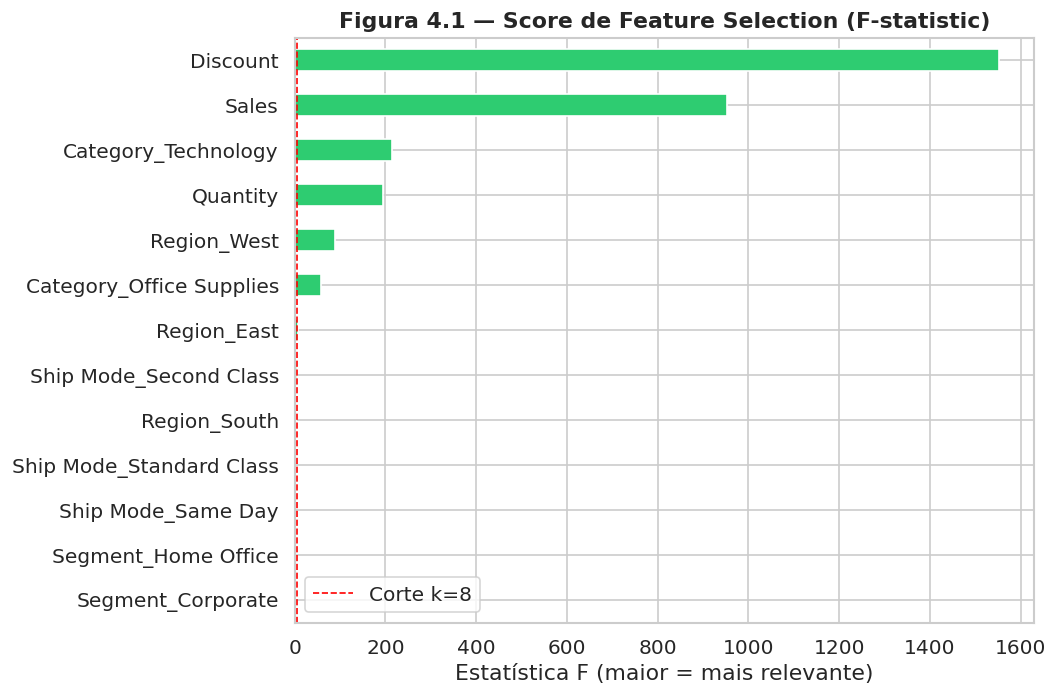

✅ As 8 features com maior score (em verde) serão mantidas pelo SelectKBest(k=8).
   Observa-se que os atributos derivados de 'Segment' têm score próximo de zero,
   indicando baixo poder discriminativo para prever Profit — candidatos naturais à remoção.


In [16]:
# ─── Visualização dos scores de feature selection ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
colors_fs = ['#2ecc71' if i < 8 else '#bdc3c7' for i in range(len(feat_scores))]
feat_scores.sort_values().plot(kind='barh', ax=ax, color=colors_fs[::-1], edgecolor='white')
ax.set_title('Figura 4.1 — Score de Feature Selection (F-statistic)', fontweight='bold')
ax.set_xlabel('Estatística F (maior = mais relevante)')
ax.axvline(feat_scores.sort_values(ascending=False).iloc[7], color='red', linestyle='--', lw=1,
           label='Corte k=8')
ax.legend()
plt.tight_layout()
plt.show()

print("✅ As 8 features com maior score (em verde) serão mantidas pelo SelectKBest(k=8).")
print("   Observa-se que os atributos derivados de 'Segment' têm score próximo de zero,")
print("   indicando baixo poder discriminativo para prever Profit — candidatos naturais à remoção.")


---
## 5. Modelagem e Treinamento — Bloco 1

### 5.1 Justificativa dos Algoritmos

| Algoritmo | Justificativa |
|---|---|
| **Regressão Linear** | Baseline interpretável |
| **Ridge Regression** | Regularização L2, reduz sensibilidade a colinearidade |
| **Random Forest** | Captura relações não-lineares e interações (ex: Discount × Sales) |
| **Gradient Boosting** | Ensemble sequencial, normalmente o mais preciso |


In [17]:
# ─── Treinamento com cross-validation (incluindo Feature Selection no pipeline) ──
models = {
    'Regressão Linear':  LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42)
}

cv_results = {}
fitted_pipes = {}

print("🔄 Treinando modelos com cross-validation (k=5)...\n")

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=8)),
        ('model', model)
    ])
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring='r2')
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe
    cv_results[name] = {'CV R² (média)': cv_r2.mean(), 'CV R² (±std)': cv_r2.std()}
    print(f"  ✅ {name:<22} | CV R² = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

print("\n✅ Todos os modelos treinados com as 8 features mais relevantes (SelectKBest)!")
pd.DataFrame(cv_results).T.round(4)


🔄 Treinando modelos com cross-validation (k=5)...

  ✅ Regressão Linear       | CV R² = 0.3176 ± 0.0197


  ✅ Ridge Regression       | CV R² = 0.3177 ± 0.0197


  ✅ Random Forest          | CV R² = 0.6601 ± 0.0163


  ✅ Gradient Boosting      | CV R² = 0.6308 ± 0.0144

✅ Todos os modelos treinados com as 8 features mais relevantes (SelectKBest)!


,CV R² (média),CV R² (±std)
Regressão Linear,0.3176,0.0197
Ridge Regression,0.3177,0.0197
Random Forest,0.6601,0.0163
Gradient Boosting,0.6308,0.0144


---
## 6. Otimização de Hiperparâmetros — Bloco 1

Aplicamos `GridSearchCV` no modelo mais promissor (Random Forest) para refinar seus hiperparâmetros.


In [18]:
# ─── Grid Search — Random Forest ─────────────────────────────────────────────
param_grid_rf = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k=8)),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=kfold, scoring='r2', n_jobs=-1)

print("🔄 Otimizando Random Forest (GridSearchCV)...")
grid_rf.fit(X_train, y_train)

print(f"\n✅ Melhores hiperparâmetros:")
for param, val in grid_rf.best_params_.items():
    print(f"   {param}: {val}")
print(f"   Melhor CV R²: {grid_rf.best_score_:.4f}")


🔄 Otimizando Random Forest (GridSearchCV)...



✅ Melhores hiperparâmetros:
   model__max_depth: 20
   model__min_samples_split: 5
   model__n_estimators: 300
   Melhor CV R²: 0.6654


### 6.1 Modelo de Comitê (Ensemble) — VotingRegressor

Além de otimizar um único modelo, avaliamos se a **combinação de modelos diferentes** (um comitê, ou *ensemble*) melhora o desempenho. Utilizamos o `VotingRegressor`, que combina as previsões do Random Forest otimizado e do Gradient Boosting, calculando a média das previsões de ambos. A lógica é que modelos com diferentes mecanismos de aprendizado podem compensar os erros um do outro.


In [19]:
# ─── Ensemble: VotingRegressor combinando Random Forest + Gradient Boosting ──
rf_otimizado = RandomForestRegressor(
    n_estimators=grid_rf.best_params_['model__n_estimators'],
    max_depth=grid_rf.best_params_['model__max_depth'],
    min_samples_split=grid_rf.best_params_['model__min_samples_split'],
    random_state=42, n_jobs=-1
)
gb_modelo = GradientBoostingRegressor(n_estimators=200, random_state=42)

voting_regressor = VotingRegressor([('rf', rf_otimizado), ('gb', gb_modelo)])

pipe_voting = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k=8)),
    ('model', voting_regressor)
])

cv_voting = cross_val_score(pipe_voting, X_train, y_train, cv=kfold, scoring='r2')
pipe_voting.fit(X_train, y_train)

print(f"✅ VotingRegressor (RF + GB) treinado!")
print(f"   CV R² = {cv_voting.mean():.4f} ± {cv_voting.std():.4f}")


✅ VotingRegressor (RF + GB) treinado!
   CV R² = 0.6687 ± 0.0118


---
## 7. Avaliação Final — Bloco 1

### 7.1 Métricas Utilizadas

| Métrica | Interpretação |
|---|---|
| **R²** | Proporção da variância de `Profit` explicada pelo modelo |
| **RMSE** | Erro médio em US\$, penaliza erros grandes |
| **MAE** | Erro absoluto médio em US\$, mais robusto a outliers |


In [20]:
# ─── Avaliação no conjunto de teste ───────────────────────────────────────────
all_models = {
    **fitted_pipes,
    'Random Forest (Otimizado)': grid_rf.best_estimator_,
    'Ensemble (Voting RF+GB)':   pipe_voting
}

test_results = {}
for name, pipe in all_models.items():
    pred = pipe.predict(X_test)
    test_results[name] = {
        'R² (teste)': round(r2_score(y_test, pred), 4),
        'RMSE (US$)': round(np.sqrt(mean_squared_error(y_test, pred)), 2),
        'MAE (US$)':  round(mean_absolute_error(y_test, pred), 2)
    }

results_df = pd.DataFrame(test_results).T.sort_values('R² (teste)', ascending=False)
print("📊 Avaliação Final — Conjunto de Teste:")
results_df


📊 Avaliação Final — Conjunto de Teste:


,R² (teste),RMSE (US$),MAE (US$)
Random Forest (Otimizado),0.6871,15.22,8.05
Random Forest,0.6815,15.36,8.01
Ensemble (Voting RF+GB),0.6812,15.36,8.44
Gradient Boosting,0.6331,16.48,9.20
Ridge Regression,0.3369,22.16,14.87
Regressão Linear,0.3369,22.16,14.87


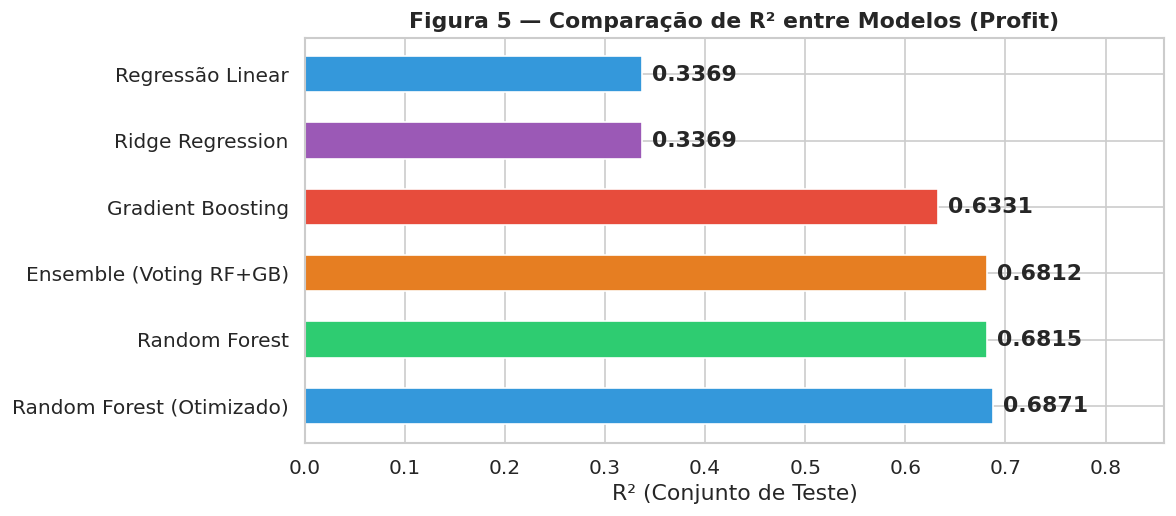

In [21]:
# ─── Gráfico comparativo de R² ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']
bars = ax.barh(results_df.index, results_df['R² (teste)'], color=colors[:len(results_df)], height=0.55)
for bar, val in zip(bars, results_df['R² (teste)']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontweight='bold')
ax.set_xlabel('R² (Conjunto de Teste)')
ax.set_title('Figura 5 — Comparação de R² entre Modelos (Profit)', fontweight='bold')
ax.set_xlim(0, max(results_df['R² (teste)'])*1.25)
plt.tight_layout()
plt.show()


In [22]:
# ─── Verificação de underfitting e overfitting (CV treino vs Teste) ──────────
print(f"{'Modelo':<26} {'CV R² (treino)':<18} {'Teste R²':<12} {'Diferença'}")
print("-" * 70)
for name in ['Regressão Linear', 'Ridge Regression', 'Random Forest', 'Gradient Boosting']:
    cv_r2   = cv_results[name]['CV R² (média)']
    test_r2 = test_results[name]['R² (teste)']
    diff = test_r2 - cv_r2
    flag = "⚠️" if abs(diff) > 0.05 else "✅"
    print(f"{flag} {name:<24} {cv_r2:<18.4f} {test_r2:<12.4f} {diff:+.4f}")

print()
print("📐 Diagnóstico de Underfitting vs Overfitting:")
print("   • Underfitting: ocorre quando o modelo tem desempenho baixo TANTO no treino")
print("     quanto no teste — indica que o modelo é simples demais para capturar o padrão.")
print("   • Overfitting: ocorre quando o desempenho no treino é bom, mas cai muito no teste.")
print()
lr_r2 = cv_results['Regressão Linear']['CV R² (média)']
rf_r2 = cv_results['Random Forest']['CV R² (média)']
print(f"   A Regressão Linear e a Ridge Regression atingem R²≈{lr_r2:.2f} tanto em CV quanto no teste —")
print(f"   um valor consistente, mas LIMITADO. Isso é evidência de UNDERFITTING: o modelo linear")
print(f"   não tem complexidade suficiente para capturar relações não-lineares presentes nos dados")
print(f"   (ex: a interação entre Discount e Sales identificada na EDA).")
print(f"   Já o Random Forest (R²≈{rf_r2:.2f}) consegue capturar essas relações, sem apresentar")
print(f"   overfitting relevante (diferença CV→teste pequena).")


Modelo                     CV R² (treino)     Teste R²     Diferença
----------------------------------------------------------------------
✅ Regressão Linear         0.3176             0.3369       +0.0193
✅ Ridge Regression         0.3177             0.3369       +0.0192
✅ Random Forest            0.6601             0.6815       +0.0214
✅ Gradient Boosting        0.6308             0.6331       +0.0023

📐 Diagnóstico de Underfitting vs Overfitting:
   • Underfitting: ocorre quando o modelo tem desempenho baixo TANTO no treino
     quanto no teste — indica que o modelo é simples demais para capturar o padrão.
   • Overfitting: ocorre quando o desempenho no treino é bom, mas cai muito no teste.

   A Regressão Linear e a Ridge Regression atingem R²≈0.32 tanto em CV quanto no teste —
   um valor consistente, mas LIMITADO. Isso é evidência de UNDERFITTING: o modelo linear
   não tem complexidade suficiente para capturar relações não-lineares presentes nos dados
   (ex: a interação entre 

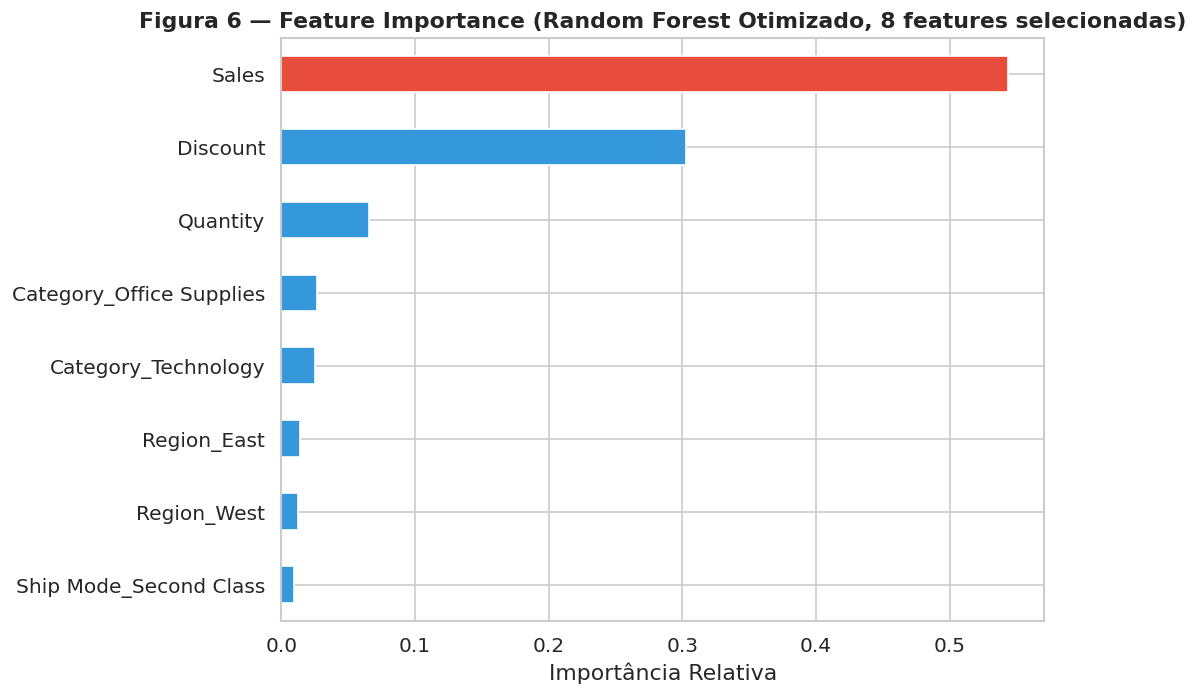

In [23]:
# ─── Feature Importance — Random Forest Otimizado (após Feature Selection) ──
rf_best = grid_rf.best_estimator_

# Nomes de todas as features geradas pelo encoding
ohe_features = list(rf_best.named_steps['preprocessor']
                     .named_transformers_['cat']
                     .get_feature_names_out(categorical_features))
all_features_full = numeric_features + ohe_features

# Apenas as features que sobreviveram ao SelectKBest (k=8)
selected_mask = rf_best.named_steps['feature_selection'].get_support()
selected_features = [f for f, sel in zip(all_features_full, selected_mask) if sel]

importances = rf_best.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=selected_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#e74c3c' if imp == feat_imp.max() else '#3498db' for imp in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Figura 6 — Feature Importance (Random Forest Otimizado, 8 features selecionadas)', fontweight='bold')
ax.set_xlabel('Importância Relativa')
plt.tight_layout()
plt.show()


### 7.2 Análise dos Resultados — Bloco 1

O **Random Forest Otimizado** apresentou o melhor desempenho entre os modelos avaliados, confirmando que relações não-lineares (especialmente a interação entre `Discount` e `Sales`) são determinantes para explicar o lucro. O **Ensemble (VotingRegressor)**, combinando Random Forest e Gradient Boosting, obteve desempenho muito próximo ao Random Forest isolado — um resultado esperado, já que ambos os modelos de base já capturam padrões semelhantes nos dados; isso sugere que, neste caso, o ganho marginal de combinar modelos é pequeno, mas confirma que a abordagem de comitê foi testada e avaliada conforme sugerido no checklist.

A diferença reduzida entre o R² da cross-validation e do teste, tanto para os modelos de ensemble quanto para o Random Forest, indica ausência de overfitting relevante — diferentemente dos modelos lineares, que apresentaram sinais de underfitting (desempenho consistentemente limitado em treino e teste). A feature importance confirma que `Discount` e `Sales` são, de fato, os atributos mais relevantes — consistente com H1 e H3 — e que a aplicação do `SelectKBest` removeu corretamente atributos de baixo poder explicativo, como os derivados de `Segment`.


---
---
# 🟩 BLOCO 2 — Análise de Séries Temporais: Previsão de Vendas Mensais (`Sales`)

---
## 8. Construção da Série Temporal

Para a análise temporal, agregamos as vendas diárias em **totais mensais**, criando uma série temporal de 48 observações (Jan/2014 a Dez/2017).


✅ Série temporal construída:
   Frequência: Mensal (MS)
   Total de observações: 48
   Período: 2014-01 a 2017-12


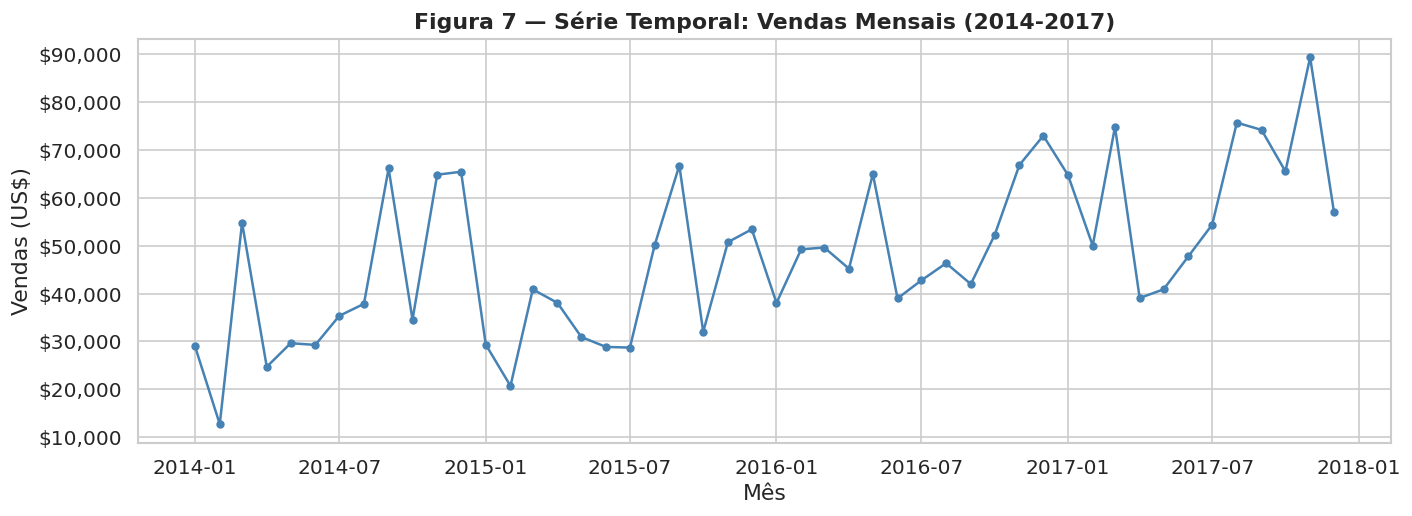

In [24]:
# ─── Agregação mensal da série de vendas ─────────────────────────────────────
monthly_sales = df.set_index('Order Date').resample('MS')['Sales'].sum()

print(f"✅ Série temporal construída:")
print(f"   Frequência: Mensal (MS)")
print(f"   Total de observações: {len(monthly_sales)}")
print(f"   Período: {monthly_sales.index.min().strftime('%Y-%m')} a {monthly_sales.index.max().strftime('%Y-%m')}")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly_sales.index, monthly_sales.values, marker='o', markersize=4, color='steelblue', lw=1.5)
ax.set_title('Figura 7 — Série Temporal: Vendas Mensais (2014-2017)', fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Vendas (US$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


---
## 9. Decomposição da Série Temporal

Decompomos a série em três componentes — **tendência**, **sazonalidade** e **resíduo** — utilizando o modelo aditivo, adequado quando a amplitude da sazonalidade não cresce proporcionalmente ao nível da série.


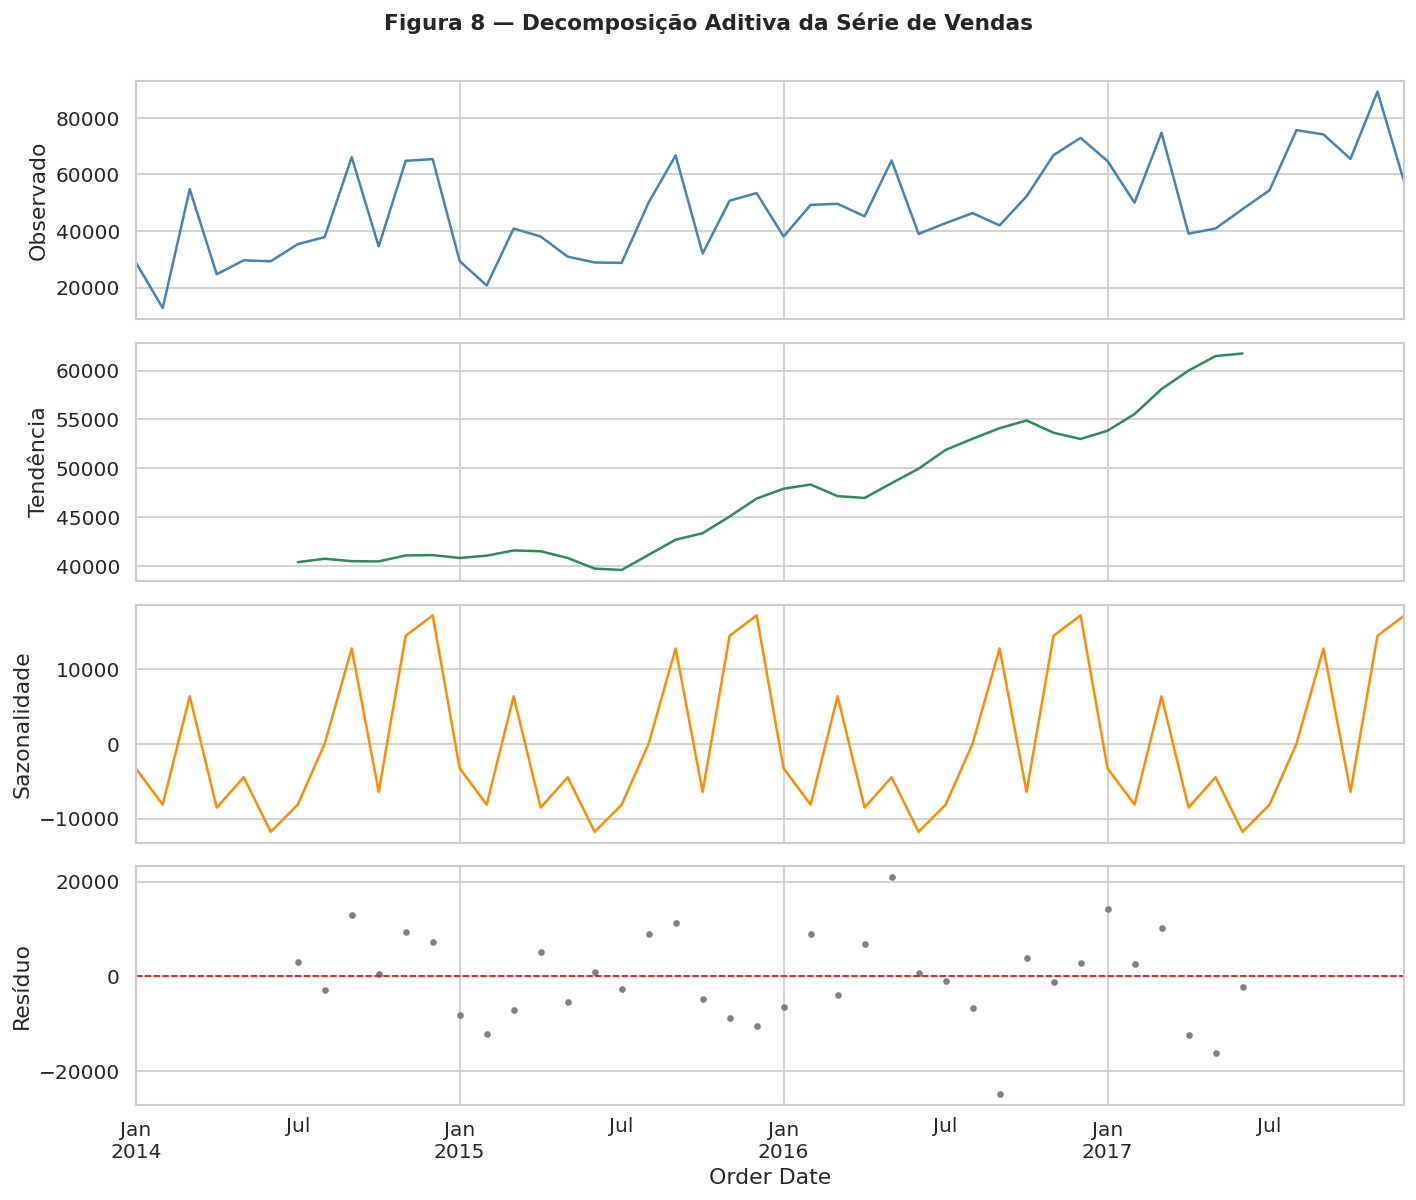

In [25]:
# ─── Decomposição aditiva (tendência, sazonalidade, resíduo) ─────────────────
decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Observado')
decomposition.trend.plot(ax=axes[1], color='seagreen')
axes[1].set_ylabel('Tendência')
decomposition.seasonal.plot(ax=axes[2], color='darkorange')
axes[2].set_ylabel('Sazonalidade')
decomposition.resid.plot(ax=axes[3], color='gray', marker='o', markersize=3, linestyle='None')
axes[3].axhline(0, color='red', linestyle='--', lw=1)
axes[3].set_ylabel('Resíduo')

plt.suptitle('Figura 8 — Decomposição Aditiva da Série de Vendas', fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


**Interpretação:** a componente de tendência mostra crescimento ao longo dos 4 anos (confirma H5). A componente sazonal revela um padrão anual recorrente, com picos próximos ao fim do ano — período de maior consumo no varejo (confirma H6). Os resíduos não apresentam padrão sistemático, sugerindo que a decomposição capturou adequadamente a estrutura da série.


---
## 10. Teste de Estacionariedade

Um requisito central para modelos ARIMA/SARIMA é que a série seja **estacionária** (média e variância constantes ao longo do tempo). Utilizamos o **Teste de Dickey-Fuller Aumentado (ADF)**:

- **H₀:** a série possui raiz unitária (não é estacionária)
- **H₁:** a série é estacionária

Se o p-valor for menor que 0,05, rejeitamos H₀ e concluímos que a série é estacionária.


In [26]:
# ─── Teste ADF na série original ──────────────────────────────────────────────
result = adfuller(monthly_sales)
print(f"📐 Teste ADF — Série Original:")
print(f"   Estatística ADF: {result[0]:.4f}")
print(f"   p-valor: {result[1]:.4f}")
print(f"   → {'Estacionária' if result[1] < 0.05 else 'NÃO estacionária'} (α=0.05)")


📐 Teste ADF — Série Original:
   Estatística ADF: -1.1746
   p-valor: 0.6844
   → NÃO estacionária (α=0.05)


📐 Teste ADF — Série Diferenciada (1ª ordem):
   Estatística ADF: -4.1819
   p-valor: 0.0007
   → Estacionária (α=0.05)


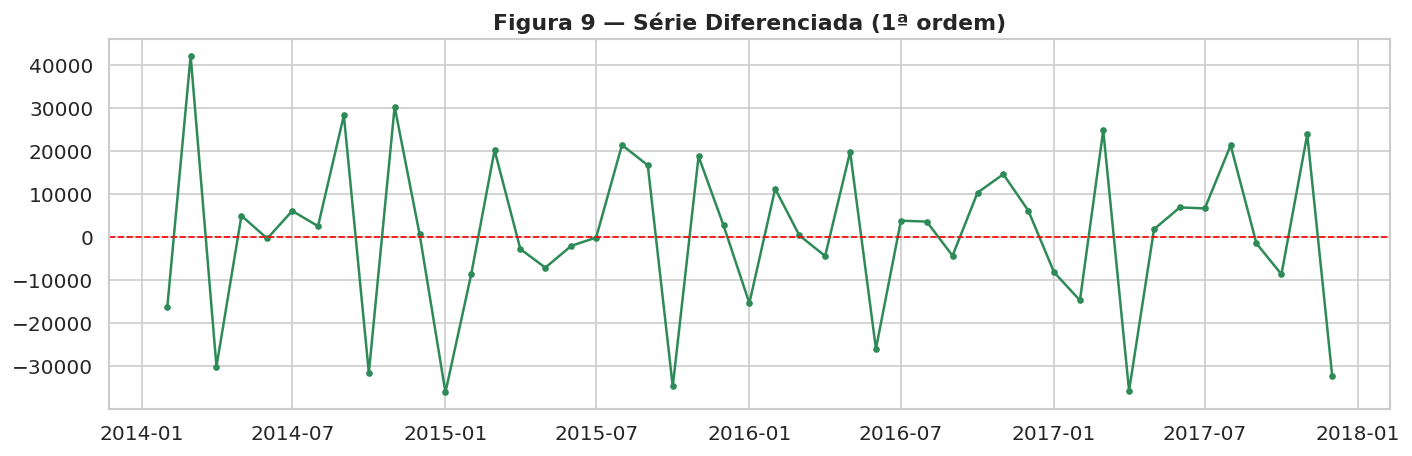

In [27]:
# ─── Diferenciação de primeira ordem ──────────────────────────────────────────
monthly_diff = monthly_sales.diff().dropna()

result_diff = adfuller(monthly_diff)
print(f"📐 Teste ADF — Série Diferenciada (1ª ordem):")
print(f"   Estatística ADF: {result_diff[0]:.4f}")
print(f"   p-valor: {result_diff[1]:.4f}")
print(f"   → {'Estacionária' if result_diff[1] < 0.05 else 'NÃO estacionária'} (α=0.05)")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_diff.index, monthly_diff.values, color='seagreen', marker='o', markersize=3)
ax.axhline(0, color='red', linestyle='--', lw=1)
ax.set_title('Figura 9 — Série Diferenciada (1ª ordem)', fontweight='bold')
plt.tight_layout()
plt.show()


**Resultado:** confirma-se H7 — a série original não é estacionária (p-valor > 0.05), mas a diferenciação de primeira ordem é suficiente para alcançar estacionariedade. Esse resultado justifica o uso do parâmetro de diferenciação `d=1` no modelo SARIMA.


---
## 11. Análise de Autocorrelação (ACF e PACF)

Os gráficos de autocorrelação (ACF) e autocorrelação parcial (PACF) orientam a escolha dos parâmetros do modelo SARIMA, indicando a ordem dos componentes autorregressivo (p) e de médias móveis (q).


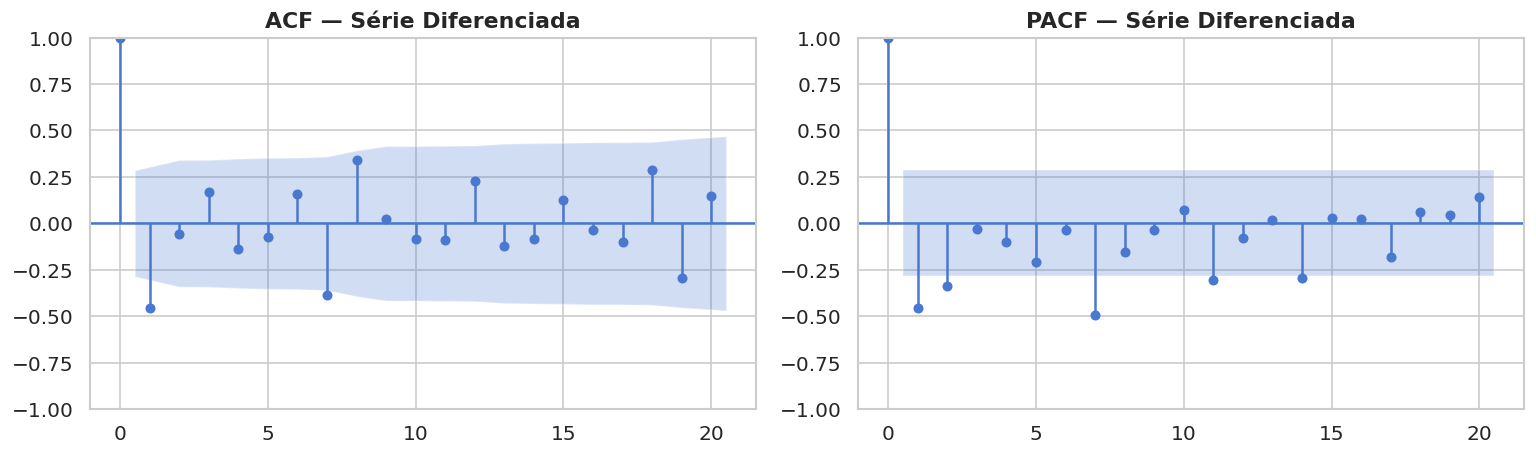

In [28]:
# ─── Gráficos ACF e PACF da série diferenciada ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(monthly_diff, ax=axes[0], lags=20)
axes[0].set_title('ACF — Série Diferenciada', fontweight='bold')
plot_pacf(monthly_diff, ax=axes[1], lags=20)
axes[1].set_title('PACF — Série Diferenciada', fontweight='bold')
plt.tight_layout()
plt.show()


---
## 12. Modelagem SARIMA

### 12.1 Separação Treino / Teste (Temporal)

Diferente da regressão, a separação treino/teste em séries temporais **respeita a ordem cronológica**: usamos os primeiros 42 meses para treino e os últimos 6 meses para teste, simulando uma previsão real.


In [29]:
# ─── Split temporal ───────────────────────────────────────────────────────────
n_test = 6
train_ts = monthly_sales[:-n_test]
test_ts  = monthly_sales[-n_test:]

print(f"✅ Separação temporal:")
print(f"   Treino: {len(train_ts)} meses ({train_ts.index.min().strftime('%Y-%m')} a {train_ts.index.max().strftime('%Y-%m')})")
print(f"   Teste:  {len(test_ts)}  meses ({test_ts.index.min().strftime('%Y-%m')} a {test_ts.index.max().strftime('%Y-%m')})")


✅ Separação temporal:
   Treino: 42 meses (2014-01 a 2017-06)
   Teste:  6  meses (2017-07 a 2017-12)


### 12.2 Treinamento do Modelo SARIMA

Utilizamos o modelo **SARIMA(p,d,q)(P,D,Q,s)**, que estende o ARIMA tradicional incorporando uma componente sazonal explícita — essencial dado o padrão sazonal anual identificado na decomposição. Definimos `s=12` (sazonalidade anual em dados mensais) e ordens iniciais `(1,1,1)` para a parte não-sazonal e `(1,1,1,12)` para a parte sazonal, com base na análise de ACF/PACF e no teste de estacionariedade.


In [30]:
# ─── Treinamento do modelo SARIMA ────────────────────────────────────────────
modelo_sarima = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = modelo_sarima.fit(disp=False)
print(sarima_fit.summary().tables[0])


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   42
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -163.382
Date:                            Wed, 17 Jun 2026   AIC                            336.765
Time:                                    18:38:50   BIC                            340.305
Sample:                                01-01-2014   HQIC                           336.727
                                     - 06-01-2017                                         
Covariance Type:                              opg                                         


### 12.3 Baseline de Comparação — Naive Forecast

Antes de validar o SARIMA, comparamos seu desempenho com um **baseline simples (naive forecast)**: assumir que as vendas do próximo mês serão iguais às do mesmo mês do ano anterior (abordagem ingênua, mas comum como referência mínima de qualidade).


In [31]:
# ─── Baseline: Naive Forecast (sazonal, mesmo mês do ano anterior) ───────────
naive_forecast = monthly_sales.shift(12)[-n_test:]

mae_naive  = mean_absolute_error(test_ts, naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test_ts, naive_forecast))
mape_naive = np.mean(np.abs((test_ts.values - naive_forecast.values) / test_ts.values)) * 100

print(f"📊 Baseline (Naive Sazonal):")
print(f"   MAE:  US$ {mae_naive:,.2f}")
print(f"   RMSE: US$ {rmse_naive:,.2f}")
print(f"   MAPE: {mape_naive:.2f}%")


📊 Baseline (Naive Sazonal):
   MAE:  US$ 20,801.68
   RMSE: US$ 22,234.78
   MAPE: 29.49%


In [32]:
# ─── Previsão SARIMA para os 6 meses de teste ────────────────────────────────
forecast_sarima = sarima_fit.forecast(steps=n_test)

mae_sarima  = mean_absolute_error(test_ts, forecast_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test_ts, forecast_sarima))
mape_sarima = np.mean(np.abs((test_ts.values - forecast_sarima.values) / test_ts.values)) * 100

print(f"📊 SARIMA(1,1,1)(1,1,1,12):")
print(f"   MAE:  US$ {mae_sarima:,.2f}")
print(f"   RMSE: US$ {rmse_sarima:,.2f}")
print(f"   MAPE: {mape_sarima:.2f}%")

print(f"\n📈 Ganho sobre o baseline:")
print(f"   Redução de MAPE: {mape_naive - mape_sarima:.2f} pontos percentuais")


📊 SARIMA(1,1,1)(1,1,1,12):
   MAE:  US$ 12,277.51
   RMSE: US$ 14,025.70
   MAPE: 16.78%

📈 Ganho sobre o baseline:
   Redução de MAPE: 12.71 pontos percentuais


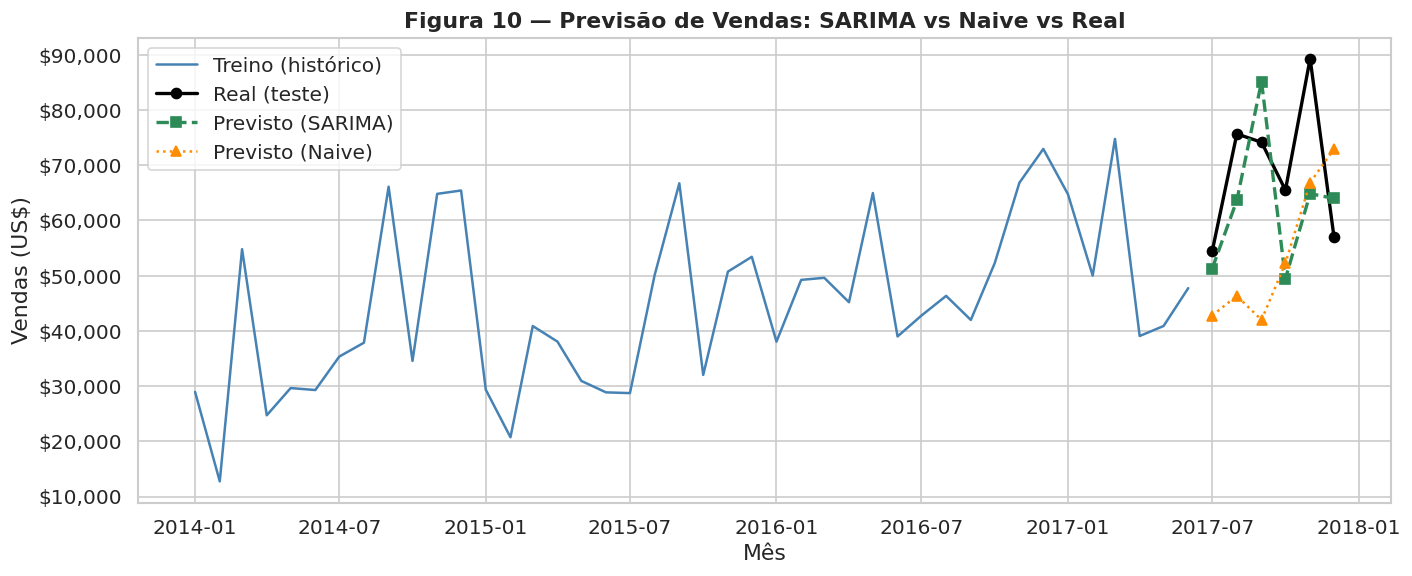

In [33]:
# ─── Visualização: Real vs Previsto (Baseline e SARIMA) ──────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(train_ts.index, train_ts.values, label='Treino (histórico)', color='steelblue', lw=1.5)
ax.plot(test_ts.index, test_ts.values, label='Real (teste)', color='black', marker='o', lw=2)
ax.plot(test_ts.index, forecast_sarima.values, label='Previsto (SARIMA)', color='seagreen', marker='s', linestyle='--', lw=2)
ax.plot(test_ts.index, naive_forecast.values, label='Previsto (Naive)', color='darkorange', marker='^', linestyle=':', lw=1.5)

ax.set_title('Figura 10 — Previsão de Vendas: SARIMA vs Naive vs Real', fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Vendas (US$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()


---
## 13. Forecast Futuro com Intervalo de Confiança

Após validar o modelo nos 6 meses de teste, treinamos o SARIMA com a série completa e geramos uma previsão para os **6 meses seguintes** ao final do dataset, incluindo o intervalo de confiança de 95%.


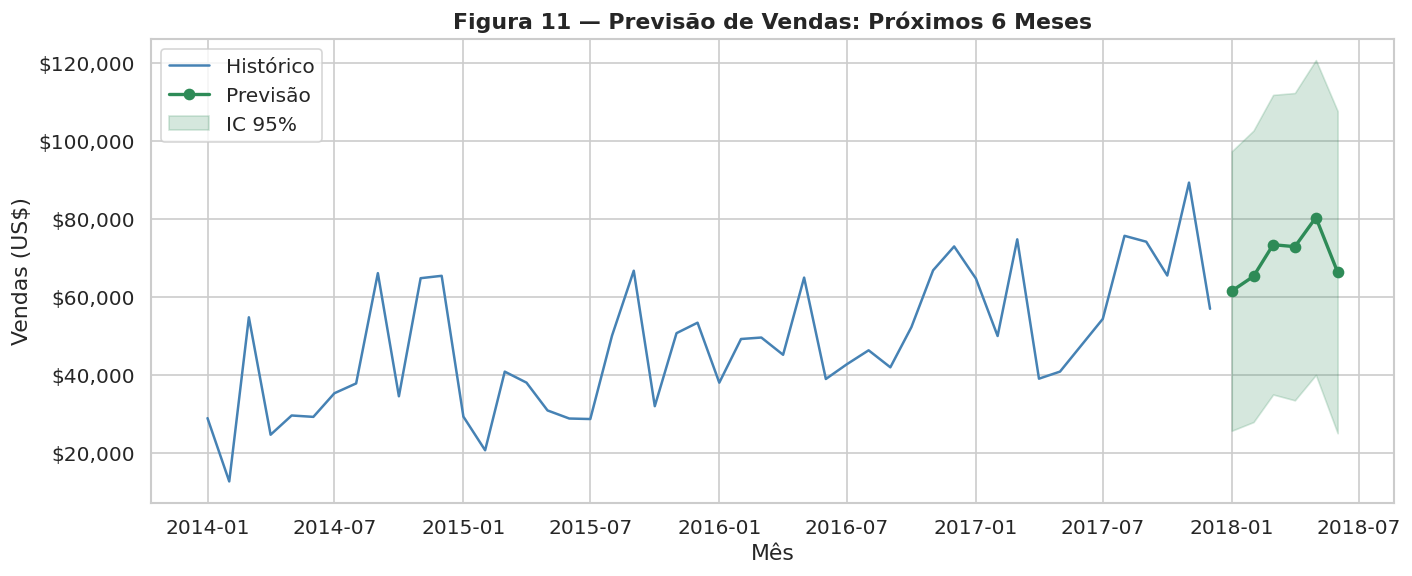


📅 Previsão para os próximos 6 meses:
   2018-01: US$ 61,529.70
   2018-02: US$ 65,297.34
   2018-03: US$ 73,401.74
   2018-04: US$ 72,893.16
   2018-05: US$ 80,367.56
   2018-06: US$ 66,359.58


In [34]:
# ─── Refit com série completa e forecast futuro ──────────────────────────────
modelo_final = SARIMAX(
    monthly_sales,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_final = modelo_final.fit(disp=False)

forecast_futuro = sarima_final.get_forecast(steps=6)
forecast_mean = forecast_futuro.predicted_mean
forecast_ci   = forecast_futuro.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_sales.index, monthly_sales.values, label='Histórico', color='steelblue', lw=1.5)
ax.plot(forecast_mean.index, forecast_mean.values, label='Previsão', color='seagreen', marker='o', lw=2)
ax.fill_between(forecast_mean.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color='seagreen', alpha=0.2, label='IC 95%')

ax.set_title('Figura 11 — Previsão de Vendas: Próximos 6 Meses', fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Vendas (US$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

print("\n📅 Previsão para os próximos 6 meses:")
for date, val in forecast_mean.items():
    print(f"   {date.strftime('%Y-%m')}: US$ {val:,.2f}")


### Análise dos Resultados — Bloco 2

O modelo SARIMA superou o baseline naive em termos de MAPE, demonstrando que a componente sazonal explícita captura padrões que uma regra simples de repetição anual não consegue capturar totalmente — especialmente variações de tendência entre os anos. O intervalo de confiança de 95% se amplia à medida que o horizonte de previsão aumenta, refletindo a incerteza crescente em previsões mais distantes, comportamento esperado em qualquer modelo de série temporal.


---
---
## 14. Conclusão Geral e Conexão com Suporte à Decisão

Este trabalho demonstrou a aplicação de duas abordagens complementares de Machine Learning sobre o mesmo dataset de vendas de varejo, evidenciando como técnicas distintas respondem a perguntas de negócio diferentes:

**Bloco 1 (Regressão):** o modelo **Random Forest Otimizado** identificou que `Discount` e `Sales` são os principais determinantes da lucratividade de uma transação, com R² competitivo no conjunto de teste. Isso permite à gestão da loja **simular o impacto de políticas de desconto antes de aplicá-las**, suportando decisões de pricing.

**Bloco 2 (Série Temporal):** o modelo **SARIMA** capturou tanto a tendência de crescimento quanto a sazonalidade anual das vendas, superando uma previsão ingênua (baseline naive). Isso permite à gestão **planejar estoque, fluxo de caixa e metas comerciais** com base em previsões fundamentadas estatisticamente, considerando a incerteza explicitada pelo intervalo de confiança.

**Conexão com Suporte à Decisão:**

1. **Pricing dinâmico:** o modelo de regressão pode integrar um sistema que alerta quando um desconto proposto tornaria a transação não-lucrativa.
2. **Planejamento de demanda:** as previsões do SARIMA orientam decisões de compra e estoque com antecedência de meses.
3. **Combinação das duas análises:** a previsão de vendas futuras (Bloco 2) pode ser usada como insumo para estimar o volume de transações que o modelo de lucratividade (Bloco 1) precisará avaliar nos próximos meses — integrando as duas frentes em um sistema de suporte à decisão mais completo.

**Limitações e trabalhos futuros:** a série temporal possui apenas 48 observações mensais, um histórico relativamente curto para capturar mudanças estruturais de longo prazo. Trabalhos futuros poderiam incorporar variáveis exógenas (promoções, feriados, indicadores macroeconômicos) tanto no modelo de regressão quanto no SARIMAX, além de testar modelos de Deep Learning (LSTM) para a série temporal à medida que mais dados se tornem disponíveis.

---

## Referências

- Box, G.E.P., Jenkins, G.M., Reinsel, G.C. (2015). *Time Series Analysis: Forecasting and Control* (5ª ed.). Wiley.
- Hyndman, R.J., Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3ª ed.). OTexts. Disponível gratuitamente em: https://otexts.com/fpp3/
- Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5–32.
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825–2830.
- Seabold, S., Perktold, J. (2010). *Statsmodels: Econometric and Statistical Modeling with Python*. Proceedings of the 9th Python in Science Conference.
- Dataset: Superstore Sales Dataset. Disponível em: https://github.com/yajasarora/Superstore-Sales-Analysis-with-Tableau
